**Trabajo Práctico 3 Pequeña red para clasificación**

**Objetivo:**

En este trabajo pràctico extenderemos el aprendizaje de los fundamentos de redes neuronales, para lo cuál adaptaremos nuestra pequeña red para un problema de clasificaciòn, para lo cuál utilizaremos la funciòn softmax. 
Tambièn aprovecharemos la mayor complejidad del problema para analizar los efectos de la cantidad (y calidad) de datos del aprendizaje.

3.1 una Clasificación bidimensional en 3 categorìas

 genere una grilla de puntos  en el rango  y los clasifique en ROJO, AZUL o AMARILLO según las reglas de la figura (con la triple frontera en el origen y la intersección en 0.5). 
 P(x,y)= (0,0.5)

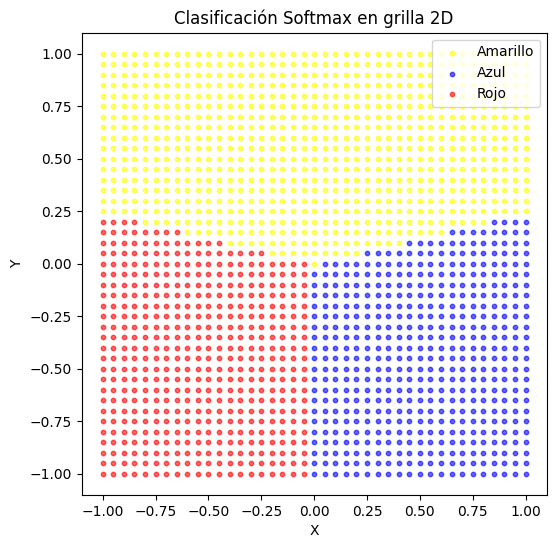

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetro: espaciamiento de la grilla
spacing = 0.05  # ajusta este valor para mayor o menor resolución

# Crear grilla de puntos en [-1,1]
x_vals = np.arange(-1, 1+spacing, spacing)
y_vals = np.arange(-1, 1+spacing, spacing)
xx, yy = np.meshgrid(x_vals, y_vals)
grid = np.c_[xx.ravel(), yy.ravel()]

# Definir logits para cada clase
# Azul-Amarillo frontera: y = 0.5*x
# Rojo-Amarillo frontera: y = -0.5*x
def logits(x, y):
    rojo = -y - 0.5*x      # favorece región izquierda
    azul = -y + 0.5*x      # favorece región derecha
    amarillo = y           # favorece región superior
    return np.array([rojo, azul, amarillo])

# Función Softmax
#Softmax: convierte los logits en probabilidades y asigna cada punto a la clase con mayor probabilidad.

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()

# Clasificar cada punto
labels = []
for (x, y) in grid:
    probs = softmax(logits(x, y))
    clase = np.argmax(probs)
    if clase == 0:
        labels.append("Rojo")
    elif clase == 1:
        labels.append("Azul")
    else:
        labels.append("Amarillo")

labels = np.array(labels).reshape(xx.shape)

# Visualización
color_map = {"Rojo":"red", "Azul":"blue", "Amarillo":"yellow"}
plt.figure(figsize=(6,6))
for c in np.unique(labels):
    mask = labels == c
    plt.scatter(xx[mask], yy[mask], c=color_map[c], label=c, s=10, alpha=0.6)

plt.title("Clasificación Softmax en grilla 2D")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

Ejercicio 3.1) 

a) Escriba un codigo que permita entrenar y evaluar la pequeña red neuronal para resolver el problema de clasificaciòn. Al igual que en el caso anterior analicè el efecto del LR,#E (learning rate) y arquitectura de la red. En este caso, como el input es bidimensional (x,y) en el intervalo (1,1), el nùmero de datos de entrada crece como n2, (n = 2/s, s=step entre puntos) lo que permite generar fàcilmente mayor cantidad de los mismos. Analicé el efecto del mismo en
relación al tiempo de entrenamiento y la capacidad de predicciòn de la red.


b) Para analizar los resultados ademas del valor de la LF final, analicè la “Accuracy” (% de
predicciones correctas) y la matriz de confusiòn

In [33]:
##se utilizara pytorch para la parte de la red neuronal, pero se mantiene el uso de numpy y matplotlib para la generación de datos y visualización.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time



In [34]:
# 1. Generación de Datos (Input bidimensional)
spacing = 0.05
x_vals = np.arange(-1, 1 + spacing, spacing)
y_vals = np.arange(-1, 1 + spacing, spacing)
xx, yy = np.meshgrid(x_vals, y_vals)
grid = np.c_[xx.ravel(), yy.ravel()]

# Etiquetas "reales" basadas en tu lógica original para supervisar el aprendizaje
def get_ground_truth(x, y):
    r = -y - 0.5*x
    a = -y + 0.5*x
    am = y
    return np.argmax([r, a, am])

y_true = np.array([get_ground_truth(px, py) for px, py in grid])

# Convertir a Tensores de PyTorch
X_train = torch.FloatTensor(grid)
y_train = torch.LongTensor(y_true)


In [35]:


# 2. Definición de la Arquitectura (Ajustable)
class SimpleNet(nn.Module):
    def __init__(self, hidden_size=10):
        super(SimpleNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size), # Entrada (x, y)
            nn.ReLU(),
            nn.Linear(hidden_size, 3)  # Salida (3 clases)
        )
        
    def forward(self, x):
        return self.net(x)



In [36]:
# 3. Hiperparámetros 
LR = 0.1
EPOCHS = 100
HIDDEN_LAYERS = 16

model = SimpleNet(HIDDEN_LAYERS)
criterion = nn.CrossEntropyLoss() # Incluye Softmax internamente
optimizer = optim.Adam(model.parameters(), lr=LR)

#######################################################33
# Lista para guardar el historial de la pérdida
loss_history = []
start_time = time.time()

# 4. Entrenamiento
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Guardamos el valor de la pérdida (usamos .item() para extraer el escalar)
    loss_history.append(loss.item())

end_time = time.time()
print(f"Tiempo de entrenamiento: {end_time - start_time:.2f} segundos")




Epoch 0, Loss: 0.9886
Tiempo de entrenamiento: 0.26 segundos


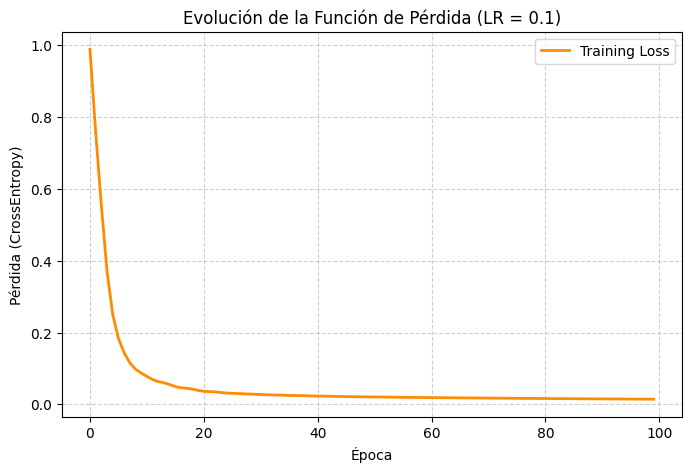

In [37]:
###visualizacion de Loss Fucnion

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Training Loss', color='darkorange', linewidth=2)
plt.title(f"Evolución de la Función de Pérdida (LR = {LR})")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()



In [38]:
# 5. Evaluación: Accuracy y Matriz de Confusión
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_train)
    y_pred = torch.argmax(y_pred_logits, dim=1)
    
accuracy = (y_pred == y_train).float().mean()
print(f"\nAccuracy Final: {accuracy:.2%}")



Accuracy Final: 99.94%


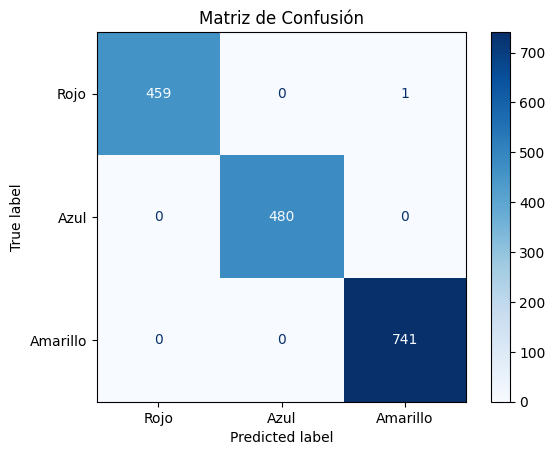

In [39]:
# Visualización de la Matriz de Confusión
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rojo", "Azul", "Amarillo"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

*ANALISIS*

Se utilizo PyTorch, que es el estándar para este tipo de tareas, para la arquitectura y el Learning Rate (LR).

LR o tasa de aprendizaje, este puede variar en estos intervalos [0.1, 0.01, 0.001, 0.0001] A numeros muy pequeños la red aprende lentamente, a numeros grandes la red puede  perder los cambios para llegar a la mejor opcion.

Arquitectura: Al ser un problema linealmente separable, solo basta con una red  Linear(2, 3). Si se incrementa el hidden_size, la red puede aprender fronteras más complejas o "curvas" si los datos lo requirieran. 

Crecimiento de datos n^2: el tiempo por época aumenta linealmente respecto al número de puntos, pero la "suavidad" de la frontera de decisión y la precisión en los bordes mejora significativamente.

**Ejercicio 3.2) Mini Bacth-training.**

Vamos a aprovechar nuestra pequeña red neuronal para profundizar sobre las técnicas de entrenamiento. Modifique su algoritmo de entrenamiento para que en vez de actualizar los paràmetros (w,b) cada època (o sea luego de utilizar todos los paràmetros), lo haga luego de realizar el fwd y backprop con una pequeña fraccion de los datos (mini batch). Recuerde que en el mini batch si hay 100 datos y el batch-size es 20, los paràmetros (w,b) se actualizan de a
pasadas de a 20, y recien cuando se completaron las 5 pasadas de 20 (o sea los 100 datos) se completa un epoca. Reentrene la red con este algoritmo y compare la velocidad de entrenamiento y el resultado final.

Utilizaciòn de ReLu como función de activación.


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time


In [45]:
# 1. Preparación de datos (Input n^2)
spacing = 0.05
x_vals = np.arange(-1, 1 + spacing, spacing)
y_vals = np.arange(-1, 1 + spacing, spacing)
xx, yy = np.meshgrid(x_vals, y_vals)
grid = np.c_[xx.ravel(), yy.ravel()]


In [46]:
# Etiquetas reales (Lógica del Ejercicio 3.1)
def get_ground_truth(x, y):
    r, a, am = -y - 0.5*x, -y + 0.5*x, y
    return np.argmax([r, a, am])

y_true = np.array([get_ground_truth(px, py) for px, py in grid])

# Convertir a Tensores y crear Dataset para Mini-Batch
dataset = TensorDataset(torch.FloatTensor(grid), torch.LongTensor(y_true))

dataset

In [ ]:

# --- PARÁMETROS AJUSTABLES ---
BATCH_SIZE = 32  # Ejercicio 3.2: Tamaño del mini-batch
LR = 0.01
EPOCHS = 100
HIDDEN_SIZE = 16

# DataLoader: se encarga de barajar y dividir los datos en batches
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Definición de la Red (Ejercicio 3.3: Uso de ReLU)
class RedRelu(nn.Module):
    def __init__(self, hidden_size):
        super(RedRelu, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.ReLU(),  # <--- Cambio de Sigmoid a ReLU
            nn.Linear(hidden_size, 3)
        )
        
    def forward(self, x):
        return self.model(x)

model = RedRelu(HIDDEN_SIZE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 3. Entrenamiento con Mini-Batch
loss_history = []
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    loss_history.append(epoch_loss / len(train_loader))


    if epoch % 100 == 0:   ### % residuo de la division entera, d cada 100 épocas
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Guardamos el valor de la pérdida (usamos .item() para extraer el escalar)
    loss_history.append(loss.item())


end_time = time.time()
print(f"Tiempo de entrenamiento: {end_time - start_time:.2f} segundos")



Epoch 0, Loss: 0.1312
Tiempo de entrenamiento: 9.36 segundos


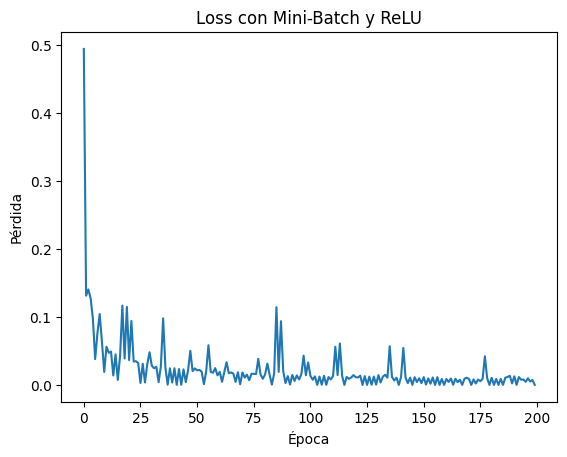

In [48]:
# Visualización de la Loss
plt.plot(loss_history)
plt.title("Loss con Mini-Batch y ReLU")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.show()

In [49]:
# 5. Evaluación: Accuracy y Matriz de Confusión con Mini-Batch y ReLU
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_train)
    y_pred = torch.argmax(y_pred_logits, dim=1)
    
accuracy = (y_pred == y_train).float().mean()
print(f"\nAccuracy Final: {accuracy:.2%}")



Accuracy Final: 99.70%


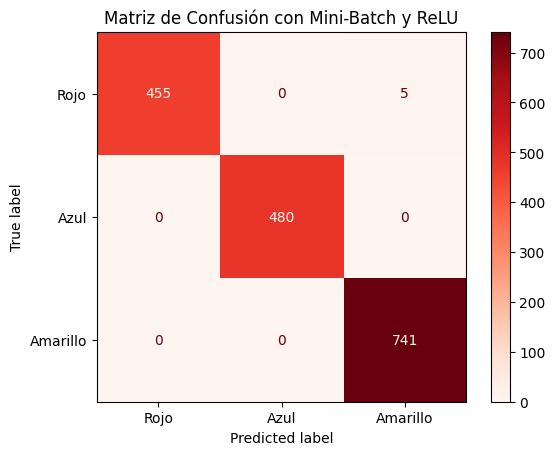

In [50]:
# Visualización de la Matriz de Confusión con Mini-Batch y ReLU
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rojo", "Azul", "Amarillo"])
disp.plot(cmap=plt.cm.Reds)
plt.title("Matriz de Confusión con Mini-Batch y ReLU")
plt.show()